In [1]:
# Import analysis Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings

In [2]:
#Filter out warnings

warnings.filterwarnings('ignore')

In [3]:
# Load dataset into a dataframe

df = pd.read_csv('online_retail_II.csv')

In [4]:
# Preview dataset

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
# Check dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [6]:
# Description of data

df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [7]:
# Check for null values

df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [8]:
# Clean up null values

df.dropna(subset=['Customer ID'])

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [9]:
# Remove cancelled invoices that were seen during pre-analysis

df[(df['Quantity'] > 0) & (df['Price'] > 0)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [10]:
# Change data type

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [12]:
# Create total sales column

df['TotalSales'] = df['Quantity'] * df['Price']

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


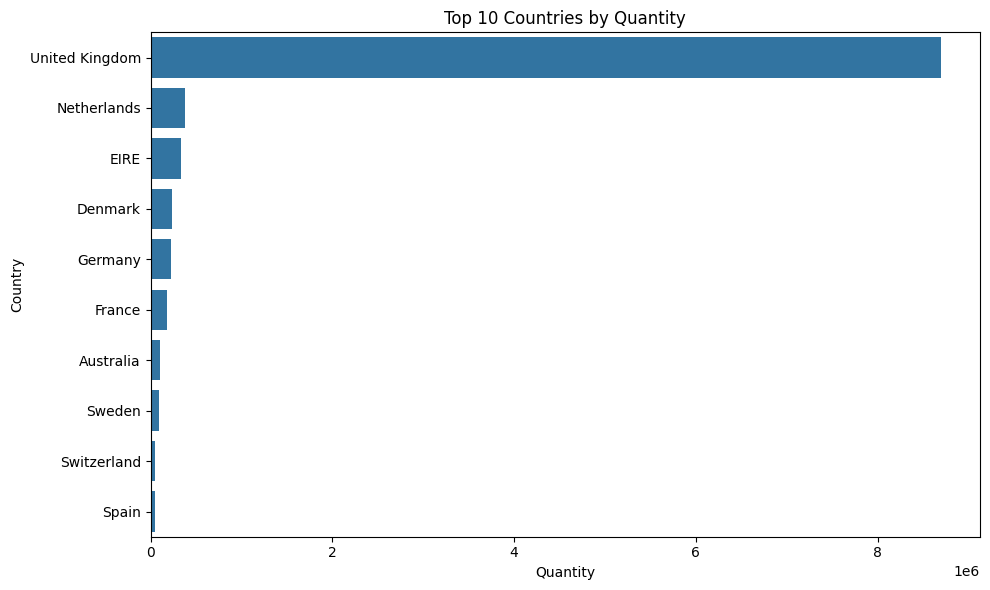

In [13]:
# Top 10 Countries

top_countries = (df.groupby('Country', as_index=False)['Quantity'].sum().sort_values(by='Quantity', ascending=False).head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=top_countries, y='Country', x='Quantity', orient='h')
plt.title('Top 10 Countries by Quantity')
plt.xlabel('Quantity')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

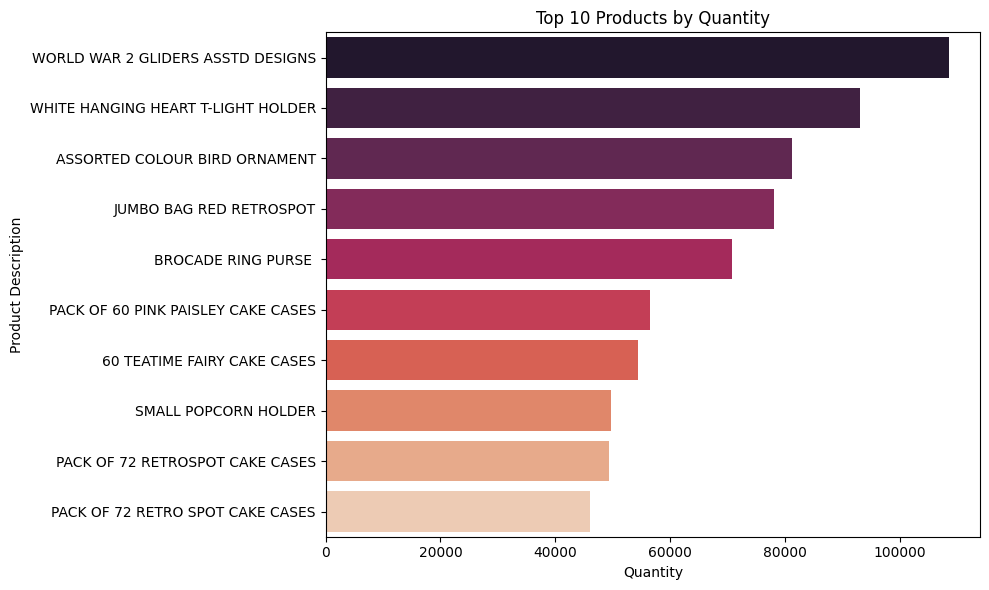

In [14]:
# Top 10 products sold

top_products = (df.groupby('Description', as_index=False)['Quantity'].sum().sort_values(by='Quantity', ascending=False).head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=top_products, y='Description', x='Quantity', orient='h', palette='rocket')
plt.title('Top 10 Products by Quantity')
plt.xlabel('Quantity')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

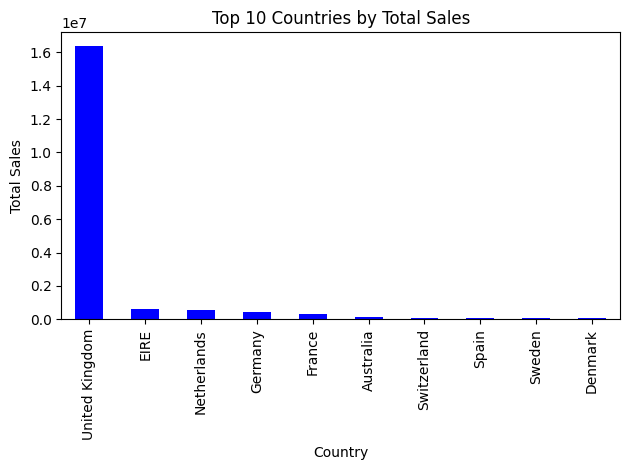

In [15]:
# Top 10 countries by Total sales

country_sales = df.groupby('Country')['TotalSales'].sum().sort_values(ascending=False).head(10)

country_sales.plot(kind='bar', color='blue')
plt.title('Top 10 Countries by Total Sales')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

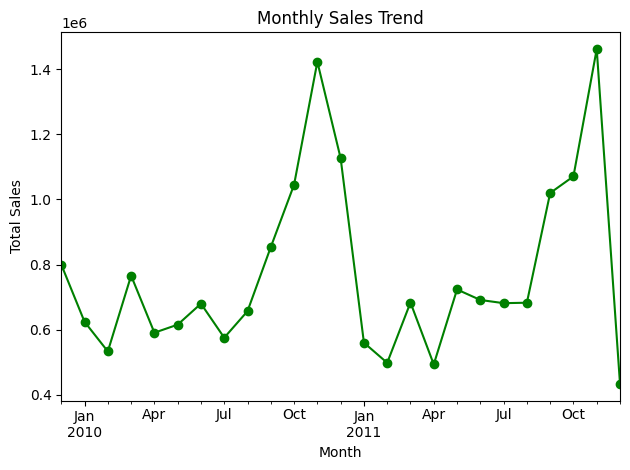

In [16]:
# Monthly sales trend

df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['TotalSales'].sum()
monthly_sales.plot(marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.ylabel('Total Sales')
plt.xticks()
plt.tight_layout()
plt.show()

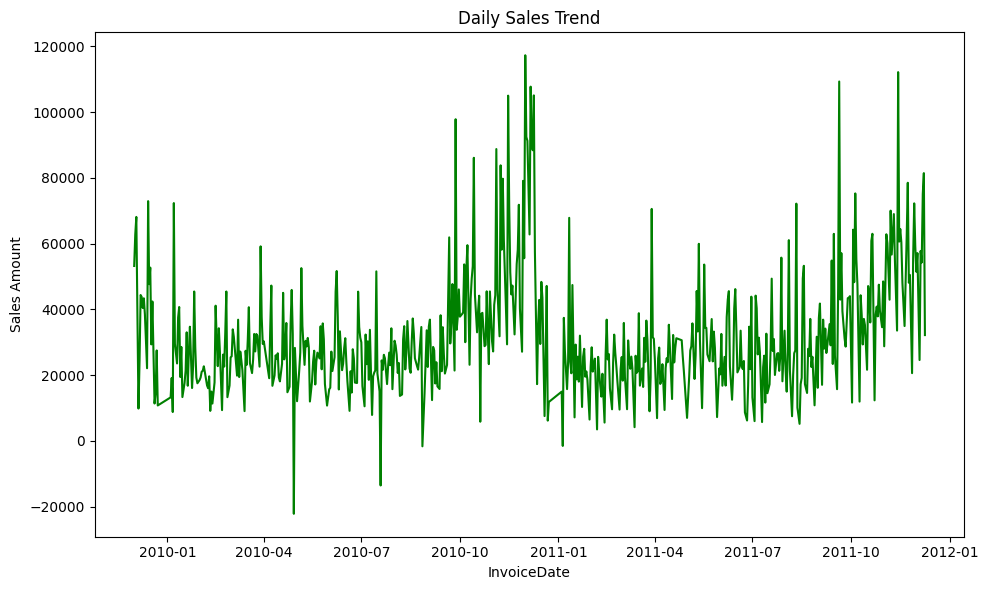

In [17]:
# Daily Sales trend

daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalSales'].sum()
plt.figure(figsize=(10,6))
daily_sales.plot(color='green')
plt.title('Daily Sales Trend')
plt.ylabel('Sales Amount')
plt.tight_layout()
plt.show()

In [18]:
df['Weekday'] = df['InvoiceDate'].dt.day_name()

In [19]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSales,Month,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12,Tuesday


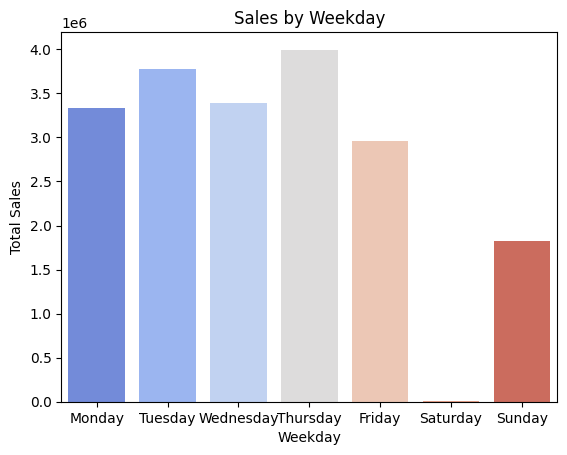

In [20]:
# Sales by Weekday

df['Weekday'] = df['InvoiceDate'].dt.day_name()
wkday_sales = df.groupby('Weekday')['TotalSales'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
sns.barplot(x=wkday_sales.index, y=wkday_sales.values, palette='coolwarm')
plt.title('Sales by Weekday')
plt.ylabel('Total Sales')
plt.show()

In [22]:
# RFM Analysis

snapshot_data = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({'InvoiceDate': lambda x: (snapshot_data - x.max()).days, 'Invoice': 'nunique', 'TotalSales': 'sum'})

rfm.rename(columns={'InvoiceDate': 'Recency', 'Invoice': 'Frequency', 'TotalSales': 'Monetary'}, inplace=True)

In [23]:
# RFM Scoring

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])

rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])

rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

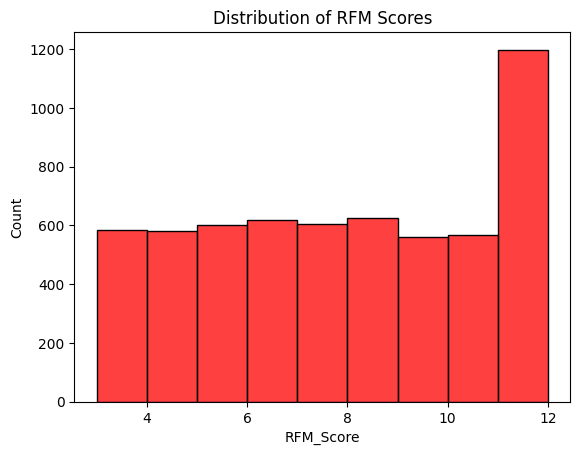

In [25]:
# RFM Plot

sns.histplot(rfm['RFM_Score'], bins=9, color='red')
plt.title('Distribution of RFM Scores')
plt.show()

In [28]:
# View top 15 of dataset

rfm.head(15)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,326,17,-64.68,2,4,1,7
12347.0,2,8,5633.32,4,3,4,11
12348.0,75,5,2019.40,3,3,3,9
12349.0,19,5,4404.54,4,3,4,11
12350.0,310,1,334.40,2,1,2,5
12351.0,375,1,300.93,2,1,1,4
12352.0,36,13,1889.21,3,4,3,10
12353.0,204,2,406.76,2,1,2,5
12354.0,232,1,1079.40,2,1,3,6


In [29]:
# Export the cleaned and RFM datasets

df.to_csv('cleaned_online_retail.csv', index=False)
rfm.to_csv('rfm_analysis.csv', index=False)

print('Successfully exported Cleaned and RFM datasets')

Successfully exported Cleaned and RFM datasets
